# Regression Diagnostics: When the Model Breaks

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain **why residual analysis is essential** — a model can produce numbers even when its assumptions are violated.
2. State and check the **four OLS assumptions**: linearity, independence, homoscedasticity, normality.
3. Construct and interpret **residual diagnostic plots** (residuals vs. fitted, Q-Q, scale-location, residuals vs. leverage).
4. Detect and test for **heteroscedasticity** using the Breusch-Pagan test (implemented from scratch).
5. Compute **leverage** ($h_{ii}$), **Cook's distance**, and **studentised residuals** to identify influential observations.
6. Use **residual-driven model building**: fit a simple model, diagnose, add complexity where the residuals demand it.
7. Build the standard **four-panel diagnostic plot** from scratch, and reproduce it with `statsmodels.graphics`.

## Prerequisites

- [01_simple_linear_regression.ipynb](01_simple_linear_regression.ipynb) — OLS estimation, residuals
- [02_multiple_regression.ipynb](02_multiple_regression.ipynb) — Hat matrix, matrix formulation of OLS
- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — Normal and $\chi^2$ distributions

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q statsmodels")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
try:
    from amstats.plotting import apply_style

    apply_style()
except ImportError:
    pass


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

# Colour palette for diagnostic plots
C_GOOD = "#00BA38"  # green — assumptions met
C_BAD = "#F8766D"  # red — assumptions violated
C_FIT = "#619CFF"  # blue — fitted line / reference
C_PT = "#404040"  # dark grey — data points

print(f"NumPy {np.__version__}")
print(f"LaTeX available: {cfg.has_latex}")

NumPy 1.26.4
LaTeX available: True


---

## 1. Why Diagnostics Matter

OLS will always give you numbers. You can always compute $\hat{\beta}$, always get an $R^2$, always obtain p-values for coefficients. The computer does not complain. But those numbers are only **trustworthy** if the model assumptions hold. When assumptions are violated:

- Coefficient estimates may be **biased** (nonlinearity, omitted variables).
- Standard errors may be **wrong** (heteroscedasticity, autocorrelation), making confidence intervals and p-values unreliable.
- Predictions may be **wildly off** outside the observed range.

The most famous illustration is **Anscombe's quartet** (1973): four datasets with identical summary statistics ($\bar{x}$, $\bar{y}$, $r$, regression line) but completely different structures. Only a plot reveals the differences.

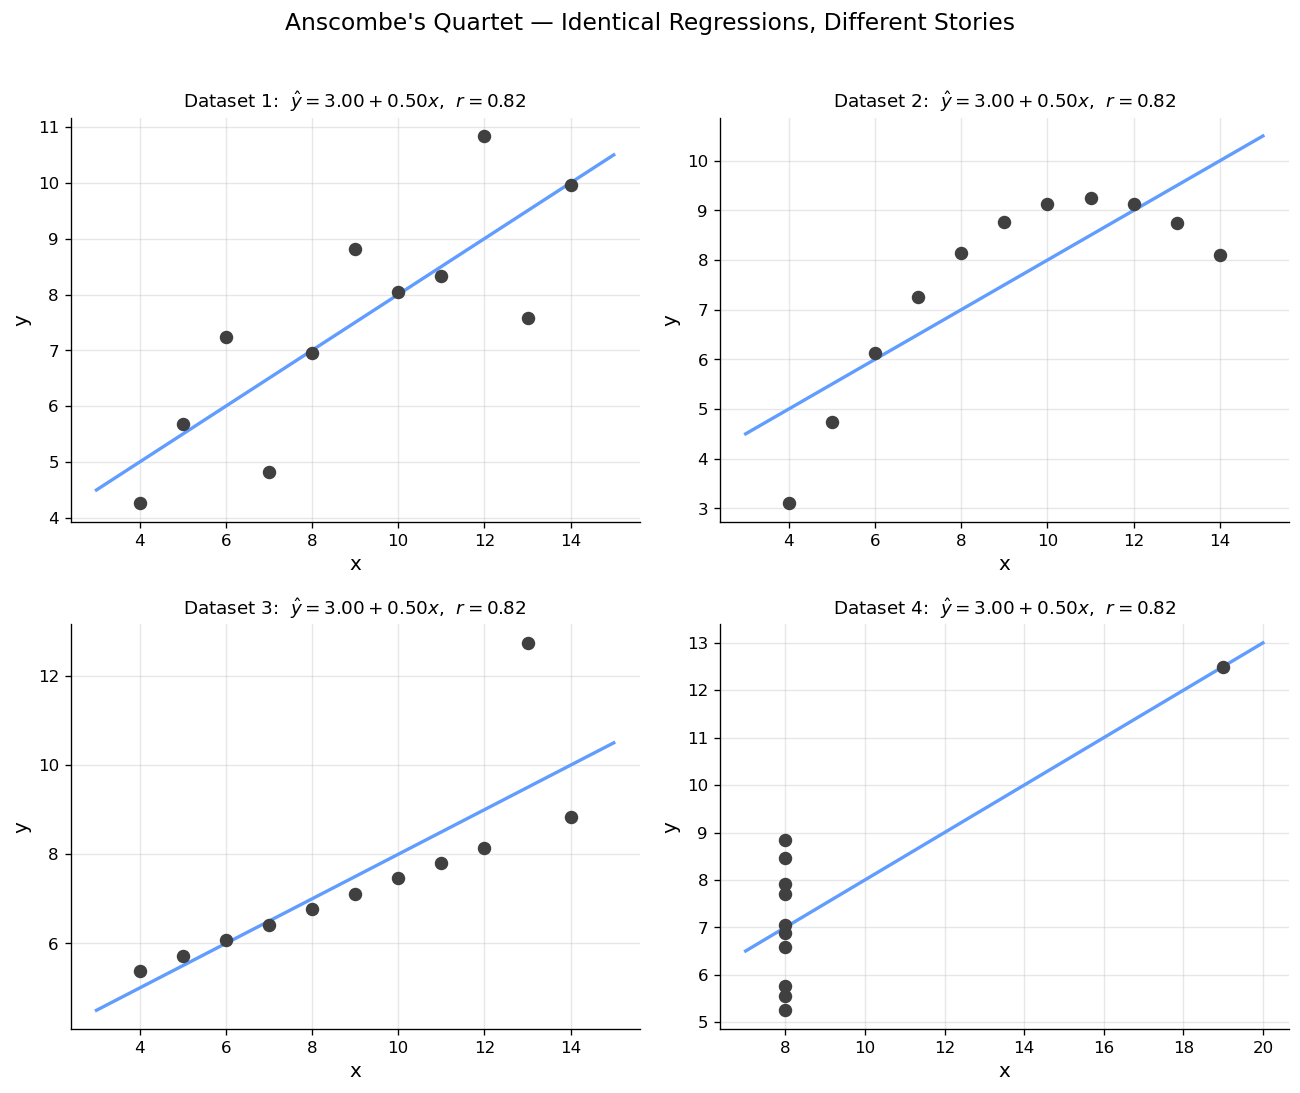

In [ ]:
# Anscombe's quartet — identical regression summaries, wildly different data
anscombe_x = [
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
]
anscombe_y = [
    [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=False, sharey=False)
for i, ax in enumerate(axes.flat):
    x = np.array(anscombe_x[i], dtype=float)
    y = np.array(anscombe_y[i], dtype=float)
    ax.scatter(x, y, color=C_PT, s=50, zorder=3)
    # Fit and plot regression line
    slope, intercept = np.polyfit(x, y, 1)
    xfit = np.linspace(x.min() - 1, x.max() + 1, 100)
    ax.plot(xfit, intercept + slope * xfit, color=C_FIT, linewidth=2)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(
        f"Dataset {i + 1}:  $\\hat{{y}} = {intercept:.2f} + {slope:.2f}x$,  $r = {r:.2f}$",
        fontsize=11,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(
    "Anscombe's Quartet — Identical Regressions, Different Stories", fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

All four datasets have nearly identical means, variances, correlations ($r \approx 0.82$), and regression lines ($\hat{y} \approx 3 + 0.5x$). Yet:

- **Dataset 1:** Assumptions roughly met — the linear model is reasonable.
- **Dataset 2:** Relationship is curvilinear — a linear model misses the structure.
- **Dataset 3:** A single outlier distorts the fit. Without it, the relationship is nearly perfect.
- **Dataset 4:** All observations have the same $x$ except one high-leverage point that single-handedly determines the slope.

The lesson: **always plot your data and residuals**. Summary statistics alone can hide critical problems.

---

## 2. The Four OLS Assumptions

The classical linear regression model $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$ relies on four assumptions about the error term $\boldsymbol{\varepsilon}$:

### (i) Linearity

$$E[y_i \mid \mathbf{x}_i] = \mathbf{x}_i^\top \boldsymbol{\beta}$$

The true relationship between the predictors and the response is linear in the parameters. If the true relationship is $y = \beta_0 + \beta_1 x + \beta_2 x^2$ and we fit $y = \beta_0 + \beta_1 x$, the linearity assumption is violated.

**How to check:** Residuals vs. fitted values plot. If the assumption holds, residuals should scatter randomly around zero with no systematic pattern.

### (ii) Independence

$$\text{Cov}(\varepsilon_i, \varepsilon_j) = 0 \quad \text{for } i \neq j$$

The errors are uncorrelated. This is violated in time series (today's error is correlated with yesterday's), spatial data, or clustered data (students within the same school).

**How to check:** Plot residuals in order of observation (or time). Look for patterns, runs, or cycles. The Durbin-Watson test formalises this for serial correlation.

### (iii) Homoscedasticity (constant variance)

$$\text{Var}(\varepsilon_i) = \sigma^2 \quad \text{for all } i$$

The variance of the errors is the same across all observations — it does not depend on the predictors or the fitted values. When the variance changes (e.g., higher variance for larger $\hat{y}$), we have **heteroscedasticity**.

**How to check:** Residuals vs. fitted values plot. Look for a "funnel" or "fan" shape. The Breusch-Pagan test provides a formal test.

### (iv) Normality of errors

$$\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

The errors are normally distributed. This is needed for **exact** inference (t-tests, F-tests, confidence intervals). With large samples, the CLT makes this less critical — inference is approximately valid even without normality.

**How to check:** Q-Q plot of residuals against the normal distribution. The Shapiro-Wilk test provides a formal test.

### What happens when assumptions are violated?

| Assumption violated | Effect on $\hat{\boldsymbol{\beta}}$ | Effect on inference                                      |
|---------------------|--------------------------------------|----------------------------------------------------------|
| Linearity           | Biased, inconsistent                 | Invalid                                                  |
| Independence        | Unbiased but inefficient             | SEs wrong, CIs/p-values unreliable                       |
| Homoscedasticity    | Unbiased                             | SEs wrong, CIs/p-values unreliable                       |
| Normality           | Unbiased                             | Exact tests invalid (but approximately OK for large $n$) |

---

## 3. Residual Plots

The residual $e_i = y_i - \hat{y}_i$ is our best estimate of the unobservable error $\varepsilon_i$. If the model is correct, residuals should behave like a random sample from $\mathcal{N}(0, \sigma^2)$ — no patterns, no trends, no changing spread.

We will generate data under "good" (assumptions met) and "bad" (assumptions violated) scenarios and compare what the diagnostic plots look like.

In [ ]:
# Helper: fit OLS and return components
def ols_fit(X, y):
    """Fit OLS via the normal equations. Returns dict of useful quantities."""
    n, p = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XtX_inv @ X.T @ y
    y_hat = X @ beta_hat
    residuals = y - y_hat
    H = X @ XtX_inv @ X.T  # hat matrix
    h = np.diag(H)  # leverages
    s2 = np.sum(residuals**2) / (n - p)  # MSE
    # Studentised (internally studentised) residuals
    r_student = residuals / np.sqrt(s2 * (1 - h))
    # Cook's distance
    cooks_d = (r_student**2 / p) * (h / (1 - h))
    return {
        "beta": beta_hat,
        "y_hat": y_hat,
        "residuals": residuals,
        "H": H,
        "leverage": h,
        "s2": s2,
        "mse": s2,
        "student_resid": r_student,
        "cooks_d": cooks_d,
        "n": n,
        "p": p,
    }

In [4]:
# Generate datasets: good model vs. violated assumptions
n = 200
x = rng.uniform(1, 10, n)
X = np.column_stack([np.ones(n), x])  # design matrix with intercept

# Good: y = 2 + 3x + N(0,1)
y_good = 2 + 3 * x + rng.normal(0, 1, n)

# Bad — nonlinear: true model is quadratic
y_nonlinear = 2 + 3 * x - 0.4 * x**2 + rng.normal(0, 1, n)

# Bad — heteroscedastic: variance grows with x
y_hetero = 2 + 3 * x + rng.normal(0, 1, n) * (0.3 * x)

# Bad — non-normal errors: heavy-tailed (t with 3 df)
y_nonnormal = 2 + 3 * x + rng.standard_t(3, n) * 1.5

fits = {
    "Good model": ols_fit(X, y_good),
    "Nonlinearity": ols_fit(X, y_nonlinear),
    "Heteroscedasticity": ols_fit(X, y_hetero),
    "Non-normal errors": ols_fit(X, y_nonnormal),
}

### 3.1 Residuals vs. Fitted Values

This is the single most informative diagnostic plot. Under correct assumptions, residuals should form a **horizontal band** centred at zero with constant width. Deviations reveal:

- **Curved pattern** $\to$ nonlinearity (misspecified functional form)
- **Funnel/fan shape** $\to$ heteroscedasticity (variance depends on $\hat{y}$)
- **Clusters or gaps** $\to$ potential grouping structure

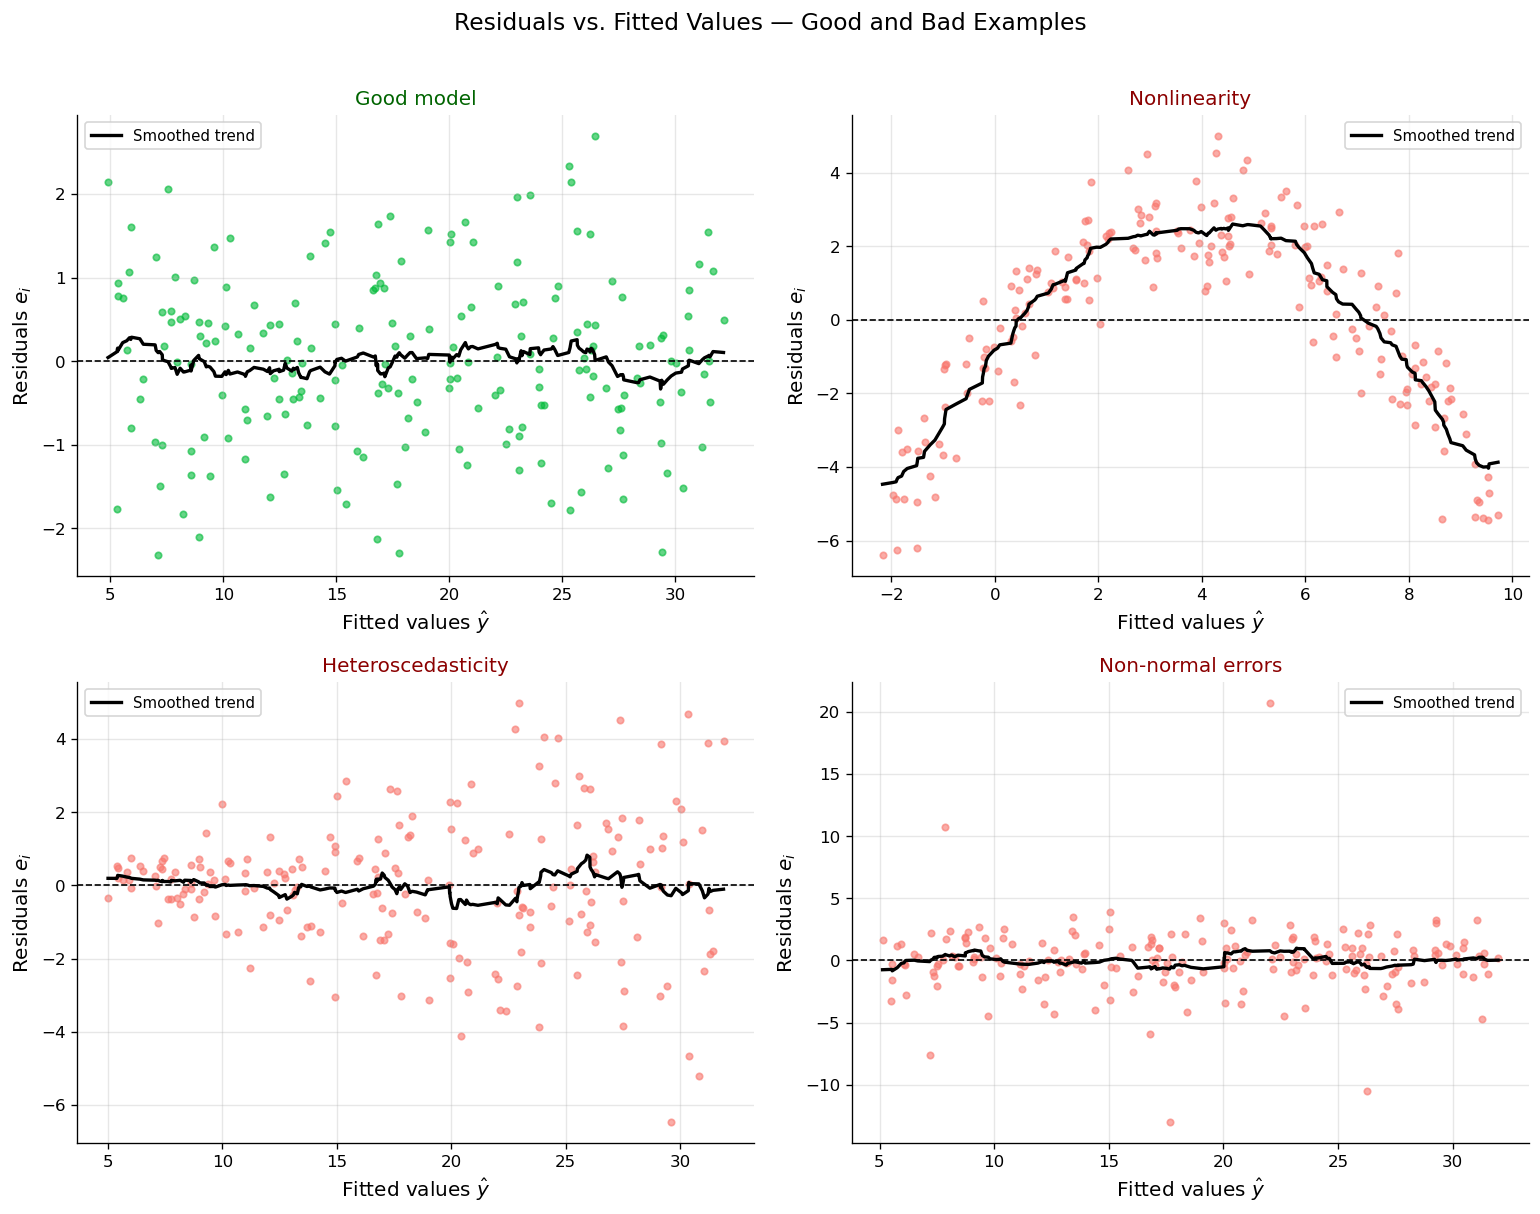

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (title, fit) in zip(axes.flat, fits.items()):
    color = C_GOOD if title == "Good model" else C_BAD
    ax.scatter(fit["y_hat"], fit["residuals"], s=15, alpha=0.6, color=color)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    # LOWESS smoother to reveal trends
    from scipy.ndimage import uniform_filter1d

    order = np.argsort(fit["y_hat"])
    smoothed = uniform_filter1d(fit["residuals"][order], size=30)
    ax.plot(
        fit["y_hat"][order],
        smoothed,
        color="black",
        linewidth=2,
        label="Smoothed trend",
    )
    ax.set_xlabel("Fitted values $\\hat{y}$")
    ax.set_ylabel("Residuals $e_i$")
    ax.set_title(
        title, fontsize=12, color="darkgreen" if title == "Good model" else "darkred"
    )
    ax.legend(fontsize=9)

fig.suptitle("Residuals vs. Fitted Values — Good and Bad Examples", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Reading the plots:**
- **Good model** (top-left): Residuals scatter randomly around zero. The smoothed trend is flat. This is what we want.
- **Nonlinearity** (top-right): The smoothed curve bows up then down — the linear model misses the quadratic structure.
- **Heteroscedasticity** (bottom-left): The spread of residuals increases with $\hat{y}$ — a classic funnel shape.
- **Non-normal errors** (bottom-right): Larger residuals appear than expected — the spread looks roughly constant, but extreme outliers hint at heavy tails. This is harder to detect here; the Q-Q plot is better for normality.

### 3.2 Q-Q Plot (Quantile-Quantile)

A Q-Q plot compares the quantiles of the residuals to the quantiles of a theoretical normal distribution. If the residuals are normally distributed, points should fall close to the 45-degree line.

- **S-shape (heavy tails):** Residuals are more extreme than expected — possibly $t$-distributed or contaminated with outliers.
- **Concave/convex curve (skew):** Residuals are asymmetric.
- **Steps or gaps:** Discreteness in the data.

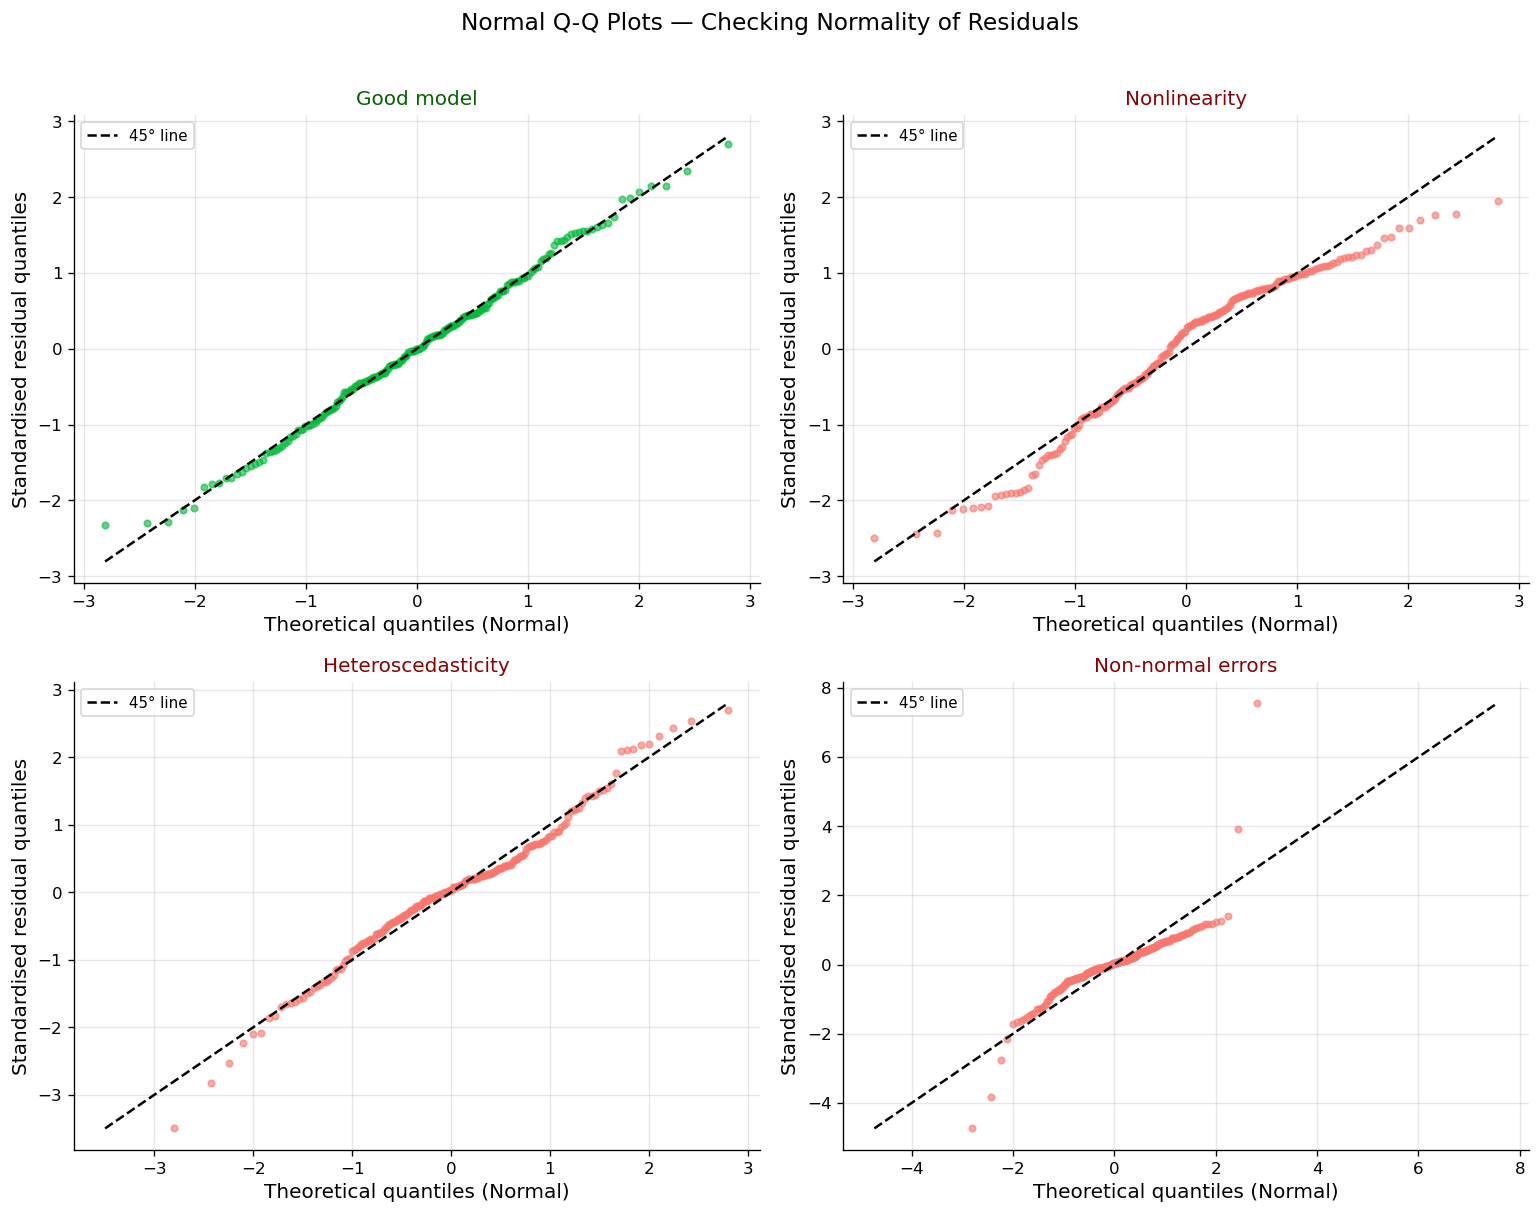

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (title, fit) in zip(axes.flat, fits.items()):
    color = C_GOOD if title == "Good model" else C_BAD
    resid = fit["residuals"]
    # Standardise
    z_resid = (resid - resid.mean()) / resid.std()
    theoretical = np.sort(stats.norm.ppf(np.linspace(0.5 / n, 1 - 0.5 / n, n)))
    empirical = np.sort(z_resid)
    ax.scatter(theoretical, empirical, s=15, alpha=0.6, color=color)
    lims = [
        min(theoretical.min(), empirical.min()),
        max(theoretical.max(), empirical.max()),
    ]
    ax.plot(lims, lims, "k--", linewidth=1.5, label="45° line")
    ax.set_xlabel("Theoretical quantiles (Normal)")
    ax.set_ylabel("Standardised residual quantiles")
    ax.set_title(
        title, fontsize=12, color="darkgreen" if title == "Good model" else "darkred"
    )
    ax.legend(fontsize=9)

fig.suptitle("Normal Q-Q Plots — Checking Normality of Residuals", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Reading the plots:**
- **Good model:** Points hug the 45-degree line closely — normality is satisfied.
- **Nonlinearity:** Systematic departure from the line — the residuals aren't random, so their distribution is distorted.
- **Heteroscedasticity:** Moderate departure, especially in the tails.
- **Non-normal errors:** Clear S-shaped departure — the tails are heavier than the normal predicts. Points peel away from the line at both ends.

### 3.3 Residuals vs. Each Predictor

When you have multiple predictors, the residuals-vs-fitted plot aggregates everything. To isolate which predictor has a misspecified functional form, plot residuals against each predictor individually. A pattern suggests you need a transformation or polynomial term for that predictor.

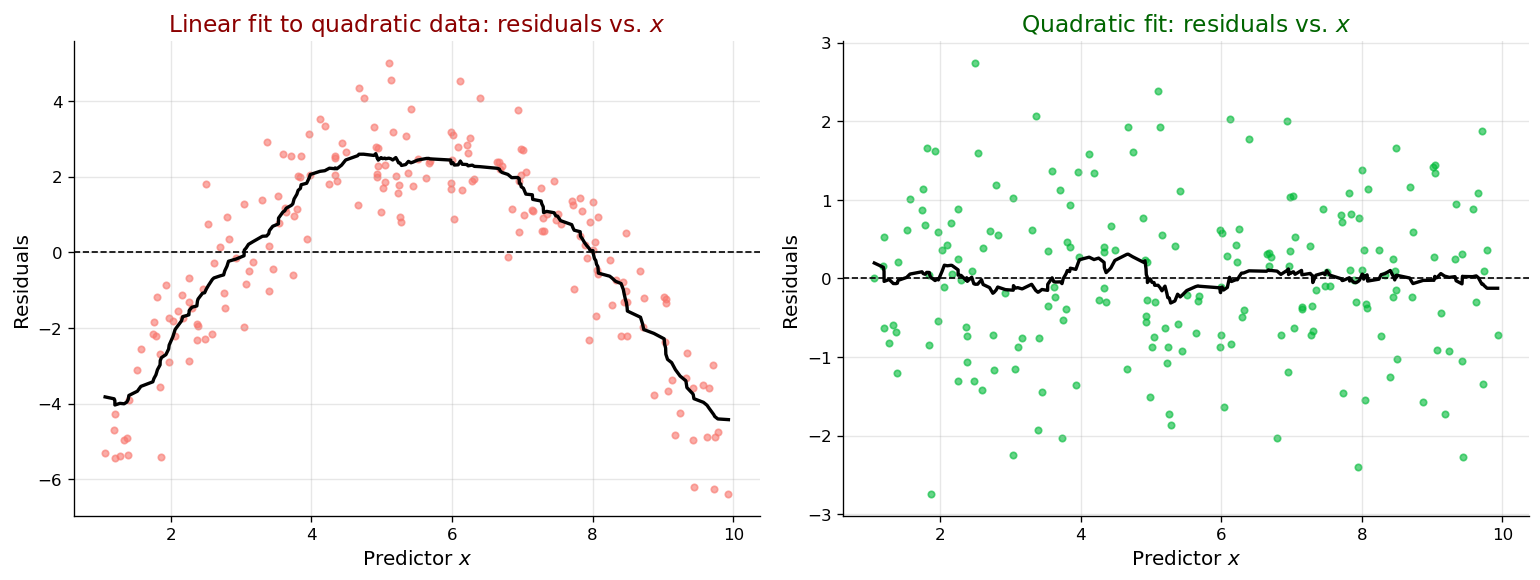

Adding x^2 to the model removes the systematic pattern in the residuals.


In [ ]:
# Example: nonlinear data — residuals vs. the predictor x
fit_nl = fits["Nonlinearity"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: residuals vs. x reveals the quadratic pattern
axes[0].scatter(x, fit_nl["residuals"], s=15, alpha=0.6, color=C_BAD)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
order = np.argsort(x)
from scipy.ndimage import uniform_filter1d

smoothed = uniform_filter1d(fit_nl["residuals"][order], size=30)
axes[0].plot(x[order], smoothed, color="black", linewidth=2)
axes[0].set_xlabel("Predictor $x$")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Linear fit to quadratic data: residuals vs. $x$", color="darkred")

# Right: fix by adding x^2 — residuals now look clean
X_quad = np.column_stack([np.ones(n), x, x**2])
fit_quad = ols_fit(X_quad, y_nonlinear)
axes[1].scatter(x, fit_quad["residuals"], s=15, alpha=0.6, color=C_GOOD)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
order = np.argsort(x)
smoothed2 = uniform_filter1d(fit_quad["residuals"][order], size=30)
axes[1].plot(x[order], smoothed2, color="black", linewidth=2)
axes[1].set_xlabel("Predictor $x$")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Quadratic fit: residuals vs. $x$", color="darkgreen")

plt.tight_layout()
plt.show()
print("Adding x^2 to the model removes the systematic pattern in the residuals.")

---

## 4. Heteroscedasticity

### 4.1 What it looks like

Heteroscedasticity means $\text{Var}(\varepsilon_i) = \sigma_i^2$ — the error variance is not constant. The classic visual signature is a **funnel** or **fan** shape in the residual plot: the spread of residuals increases (or decreases) systematically with $\hat{y}$ or a predictor.

### 4.2 Consequences

Under heteroscedasticity:
- $\hat{\boldsymbol{\beta}}$ is **still unbiased** — OLS gets the right answer on average.
- But $\hat{\boldsymbol{\beta}}$ is **no longer BLUE** (Best Linear Unbiased Estimator) — there exist more efficient estimators (e.g., WLS).
- The usual standard errors $\hat{\text{SE}}(\hat{\beta}_j)$ are **wrong**. This means:
  - Confidence intervals have incorrect coverage.
  - p-values are unreliable.
  - t-tests and F-tests may reject too often or too rarely.

### 4.3 The Breusch-Pagan Test — From Scratch

The Breusch-Pagan test asks: *do the squared residuals depend on the predictors?* If the variance is truly constant, regressing $e_i^2$ on $\mathbf{x}_i$ should produce no relationship.

**Procedure:**

1. Fit the original model, obtain residuals $e_i$.
2. Compute $g_i = e_i^2 / \hat{\sigma}^2$ where $\hat{\sigma}^2 = \frac{1}{n}\sum e_i^2$.
3. Regress $g_i$ on the original predictors $\mathbf{X}$.
4. The test statistic is $\text{BP} = \frac{1}{2} \cdot \text{ESS}$ (explained sum of squares from step 3).
5. Under $H_0$ (homoscedasticity), $\text{BP} \sim \chi^2_{p-1}$ where $p-1$ is the number of predictors (excluding intercept).

Equivalently, $\text{BP} = nR^2$ from the auxiliary regression in step 3.

In [ ]:
def breusch_pagan_test(X, residuals):
    """Breusch-Pagan test for heteroscedasticity (from scratch).

    Parameters
    ----------
    X : array (n, p) — design matrix including intercept column
    residuals : array (n,) — OLS residuals from the original model

    Returns
    -------
    bp_stat : float — test statistic
    p_value : float — p-value from chi-squared distribution
    """
    n = len(residuals)
    sigma2_hat = np.sum(residuals**2) / n

    # Normalised squared residuals
    g = residuals**2 / sigma2_hat

    # Auxiliary regression: g on X
    aux_fit = ols_fit(X, g)
    g_hat = aux_fit["y_hat"]

    # ESS of auxiliary regression
    ess = np.sum((g_hat - g.mean()) ** 2)
    bp_stat = ess / 2.0

    # Degrees of freedom = number of predictors (excluding intercept)
    df = X.shape[1] - 1
    p_value = 1 - stats.chi2.cdf(bp_stat, df)

    return bp_stat, p_value

In [ ]:
# Test on our good and heteroscedastic datasets
print("Breusch-Pagan test for heteroscedasticity")
print("=" * 50)
print(f"H0: Constant variance (homoscedasticity)")
print(f"H1: Variance depends on predictors\n")

for label, ydata in [("Good model", y_good), ("Heteroscedastic", y_hetero)]:
    fit = ols_fit(X, ydata)
    bp, pval = breusch_pagan_test(X, fit["residuals"])
    verdict = (
        "REJECT H0 — heteroscedasticity detected"
        if pval < 0.05
        else "Fail to reject H0"
    )
    print(f"{label:20s}  BP = {bp:7.2f},  p = {pval:.4f}  =>  {verdict}")

Breusch-Pagan test for heteroscedasticity
H0: Constant variance (homoscedasticity)
H1: Variance depends on predictors

Good model            BP =    0.15,  p = 0.6942  =>  Fail to reject H0
Heteroscedastic       BP =   55.00,  p = 0.0000  =>  REJECT H0 — heteroscedasticity detected


In [10]:
# Verify against statsmodels
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

print("\nVerification with statsmodels:")
print("-" * 50)
for label, ydata in [("Good model", y_good), ("Heteroscedastic", y_hetero)]:
    model = sm.OLS(ydata, X).fit()
    bp, pval, _, _ = het_breuschpagan(model.resid, X)
    print(f"{label:20s}  BP = {bp:7.2f},  p = {pval:.4f}")


Verification with statsmodels:
--------------------------------------------------
Good model            BP =    0.18,  p = 0.6732
Heteroscedastic       BP =   38.51,  p = 0.0000


Our from-scratch implementation matches `statsmodels`. For the good model, we fail to reject (no evidence of heteroscedasticity). For the heteroscedastic data, we strongly reject — the variance is not constant.

**What to do about heteroscedasticity:**
- **Robust standard errors** (HC0-HC3): Keep OLS estimates but correct the standard errors. This is the most common fix.
- **Weighted Least Squares (WLS):** If you know the variance structure, weight observations by $1/\sigma_i^2$.
- **Transform the response:** log or square-root transformations can stabilise variance.

---

## 5. Leverage and Influence

Not all observations contribute equally to the regression fit. Some points have an outsized effect on $\hat{\boldsymbol{\beta}}$. We need to distinguish:

- **Outlier:** A point with a large residual — it doesn't fit the pattern of the other data.
- **High-leverage point:** A point with unusual predictor values — it's far from the centre of the $\mathbf{X}$-space.
- **Influential point:** A point that substantially changes the fit when removed. An influential point is typically *both* an outlier and high-leverage.

### 5.1 The Hat Matrix and Leverage

Recall from the matrix formulation of OLS that the fitted values are:

$$\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}, \quad \text{where } \mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$$

$\mathbf{H}$ is the **hat matrix** — it puts the "hat" on $\mathbf{y}$. The diagonal element $h_{ii}$ is the **leverage** of observation $i$:

$$h_{ii} = \mathbf{x}_i^\top (\mathbf{X}^\top\mathbf{X})^{-1} \mathbf{x}_i$$

**Properties of leverage:**
- $0 \leq h_{ii} \leq 1$
- $\sum_{i=1}^n h_{ii} = p$ (number of parameters, including intercept)
- Average leverage: $\bar{h} = p/n$
- **Rule of thumb:** $h_{ii} > 2p/n$ is "high leverage"

**Interpretation:** $h_{ii}$ measures how much $\hat{y}_i$ depends on the observed $y_i$ itself (rather than on other observations). A high-leverage point is its own best predictor — it pulls the regression line toward itself.

### 5.2 Studentised Residuals

Raw residuals $e_i$ have unequal variances even under homoscedasticity: $\text{Var}(e_i) = \sigma^2(1 - h_{ii})$. High-leverage points tend to have *smaller* residuals because the line is pulled toward them.

We standardise to get **internally studentised residuals:**

$$r_i = \frac{e_i}{\hat{\sigma}\sqrt{1 - h_{ii}}}$$

Under the model assumptions, $r_i$ has approximately unit variance. Points with $|r_i| > 2$ or $|r_i| > 3$ are potential outliers.

### 5.3 Cook's Distance

Cook's distance combines leverage and residual size into a single measure of influence:

$$D_i = \frac{r_i^2}{p} \cdot \frac{h_{ii}}{1 - h_{ii}}$$

Equivalently, $D_i$ measures how much all fitted values change when observation $i$ is deleted. It's the (scaled) distance between $\hat{\boldsymbol{\beta}}$ and $\hat{\boldsymbol{\beta}}_{(-i)}$ (the estimate without observation $i$).

**Rule of thumb:** $D_i > 4/n$ or $D_i > 1$ flags an influential observation.

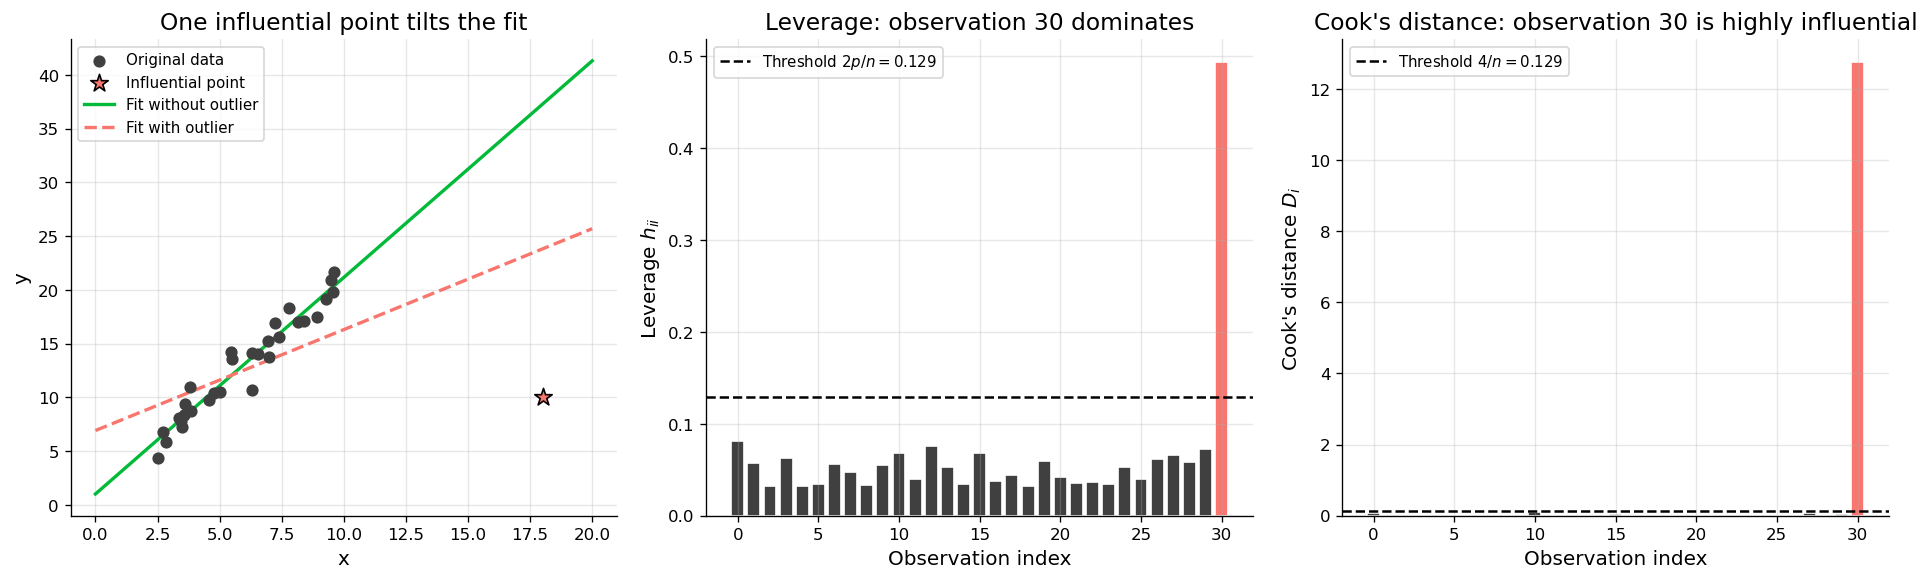


Slope without outlier: 2.015
Slope with outlier:    0.939

Outlier leverage: 0.494  (threshold: 0.129)
Outlier Cook's D: 12.763  (threshold: 0.129)


In [ ]:
# Concrete example: leverage and influence with an outlier
np.random.seed(42)
n_demo = 30
x_demo = rng.uniform(2, 10, n_demo)
y_demo = 1 + 2 * x_demo + rng.normal(0, 1, n_demo)

# Add one influential point: high leverage AND outlier
x_infl = np.append(x_demo, 18.0)  # far from other x values (high leverage)
y_infl = np.append(y_demo, 10.0)  # far from the true line at x=18 (y should be ~37)

X_demo = np.column_stack([np.ones(n_demo), x_demo])
X_infl = np.column_stack([np.ones(n_demo + 1), x_infl])

fit_clean = ols_fit(X_demo, y_demo)
fit_infl = ols_fit(X_infl, y_infl)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Data with and without influential point
ax = axes[0]
ax.scatter(x_demo, y_demo, color=C_PT, s=40, zorder=3, label="Original data")
ax.scatter(
    18.0,
    10.0,
    color=C_BAD,
    s=120,
    zorder=4,
    marker="*",
    edgecolors="black",
    label="Influential point",
)
xline = np.linspace(0, 20, 100)
ax.plot(
    xline,
    fit_clean["beta"][0] + fit_clean["beta"][1] * xline,
    color=C_GOOD,
    linewidth=2,
    label="Fit without outlier",
)
ax.plot(
    xline,
    fit_infl["beta"][0] + fit_infl["beta"][1] * xline,
    color=C_BAD,
    linewidth=2,
    linestyle="--",
    label="Fit with outlier",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("One influential point tilts the fit")
ax.legend(fontsize=9)

# Panel 2: Leverage
ax = axes[1]
threshold_h = 2 * 2 / (n_demo + 1)  # 2p/n
colors_h = [C_BAD if h > threshold_h else C_PT for h in fit_infl["leverage"]]
ax.bar(range(n_demo + 1), fit_infl["leverage"], color=colors_h, edgecolor="white")
ax.axhline(
    threshold_h,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold $2p/n = {threshold_h:.3f}$",
)
ax.set_xlabel("Observation index")
ax.set_ylabel("Leverage $h_{ii}$")
ax.set_title("Leverage: observation 30 dominates")
ax.legend(fontsize=9)

# Panel 3: Cook's distance
ax = axes[2]
threshold_d = 4 / (n_demo + 1)
colors_d = [C_BAD if d > threshold_d else C_PT for d in fit_infl["cooks_d"]]
ax.bar(range(n_demo + 1), fit_infl["cooks_d"], color=colors_d, edgecolor="white")
ax.axhline(
    threshold_d,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold $4/n = {threshold_d:.3f}$",
)
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance $D_i$")
ax.set_title("Cook's distance: observation 30 is highly influential")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nSlope without outlier: {fit_clean['beta'][1]:.3f}")
print(f"Slope with outlier:    {fit_infl['beta'][1]:.3f}")
print(
    f"\nOutlier leverage: {fit_infl['leverage'][-1]:.3f}  (threshold: {threshold_h:.3f})"
)
print(
    f"Outlier Cook's D: {fit_infl['cooks_d'][-1]:.3f}  (threshold: {threshold_d:.3f})"
)

The influential point (observation 30) has extremely high leverage *and* a large residual, giving it a Cook's distance far above the threshold. Removing it changes the slope dramatically — this single point is driving the regression results.

**Important nuance:** A high-leverage point is not automatically bad. If it has a small residual (i.e., it follows the same pattern as the rest of the data), it *stabilises* the fit. It only becomes dangerous when it's also an outlier — pulling the fit away from where it should be.

---

## 6. Residual-Driven Model Building

A standard approach to regression modelling is iterative:

1. **Start simple.** Fit the simplest reasonable model.
2. **Look at the residuals.** Do they show patterns? Which assumption is violated?
3. **Fix what the residuals tell you.** Add a polynomial term, transform a variable, handle an outlier.
4. **Repeat.** Check the new model's residuals. Stop when they look like random noise.

This is the scientific method applied to modelling: propose, test, revise.

### Worked Example: Simulated Nonlinear Data with Heteroscedasticity

In [12]:
# True model: y = 5 + 2x - 0.15x^2 + noise that grows with x
n_ex = 150
x_ex = rng.uniform(1, 15, n_ex)
noise = rng.normal(0, 1, n_ex) * (0.5 + 0.2 * x_ex)
y_ex = 5 + 2 * x_ex - 0.15 * x_ex**2 + noise

print("Step 1: Fit a simple linear model y = b0 + b1*x")
X1 = np.column_stack([np.ones(n_ex), x_ex])
fit1 = ols_fit(X1, y_ex)
print(f"  beta_hat = [{fit1['beta'][0]:.3f}, {fit1['beta'][1]:.3f}]")
bp1, bp1_p = breusch_pagan_test(X1, fit1["residuals"])
print(f"  Breusch-Pagan: BP = {bp1:.2f}, p = {bp1_p:.4f}")

Step 1: Fit a simple linear model y = b0 + b1*x
  beta_hat = [12.230, -0.406]
  Breusch-Pagan: BP = 7.53, p = 0.0061


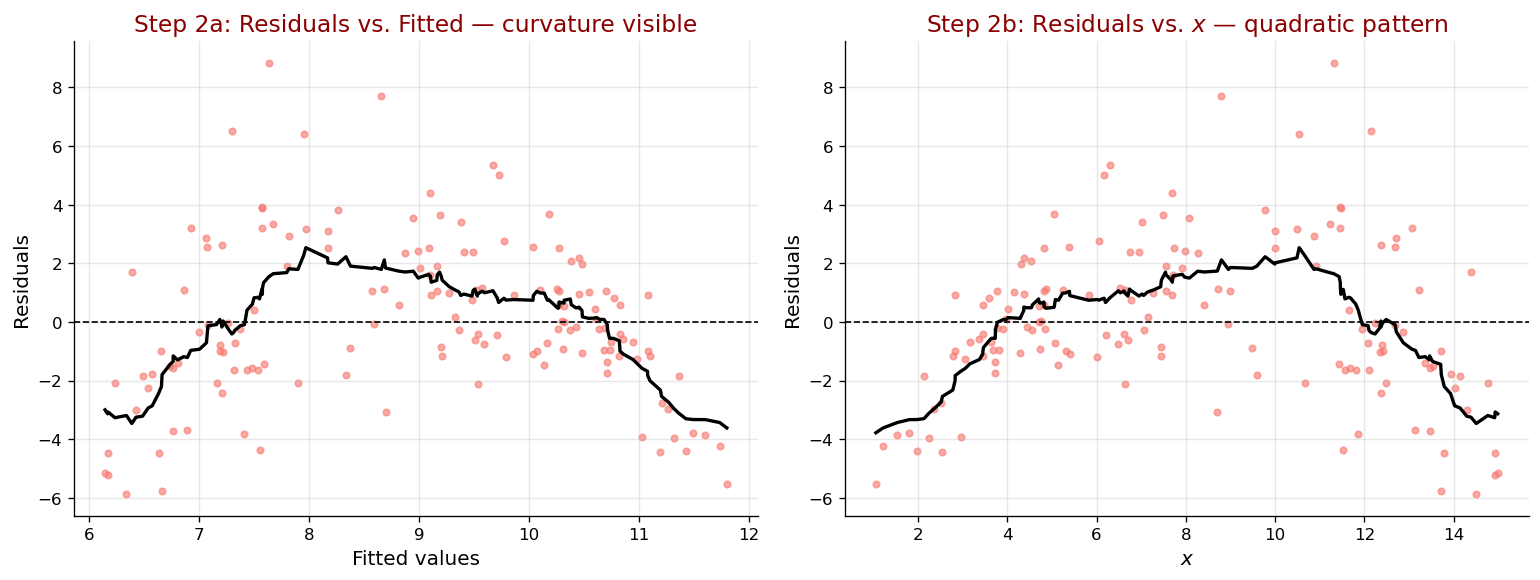

Diagnosis: Clear curvature => add x^2 term.
Also: spread may increase with x => possible heteroscedasticity.


In [13]:
# Step 2: Look at residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs fitted
axes[0].scatter(fit1["y_hat"], fit1["residuals"], s=15, alpha=0.6, color=C_BAD)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
order = np.argsort(fit1["y_hat"])
smoothed = uniform_filter1d(fit1["residuals"][order], size=20)
axes[0].plot(fit1["y_hat"][order], smoothed, color="black", linewidth=2)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Step 2a: Residuals vs. Fitted — curvature visible", color="darkred")

# Residuals vs x
axes[1].scatter(x_ex, fit1["residuals"], s=15, alpha=0.6, color=C_BAD)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
order_x = np.argsort(x_ex)
smoothed_x = uniform_filter1d(fit1["residuals"][order_x], size=20)
axes[1].plot(x_ex[order_x], smoothed_x, color="black", linewidth=2)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Step 2b: Residuals vs. $x$ — quadratic pattern", color="darkred")

plt.tight_layout()
plt.show()
print("Diagnosis: Clear curvature => add x^2 term.")
print("Also: spread may increase with x => possible heteroscedasticity.")

In [ ]:
# Step 3: Add quadratic term
print("Step 3: Fit y = b0 + b1*x + b2*x^2")
X2 = np.column_stack([np.ones(n_ex), x_ex, x_ex**2])
fit2 = ols_fit(X2, y_ex)
print(
    f"  beta_hat = [{fit2['beta'][0]:.3f}, {fit2['beta'][1]:.3f}, {fit2['beta'][2]:.4f}]"
)
bp2, bp2_p = breusch_pagan_test(X2, fit2["residuals"])
print(f"  Breusch-Pagan: BP = {bp2:.2f}, p = {bp2_p:.4f}")

Step 3: Fit y = b0 + b1*x + b2*x^2
  beta_hat = [5.436, 1.714, -0.1280]
  Breusch-Pagan: BP = 21.68, p = 0.0000


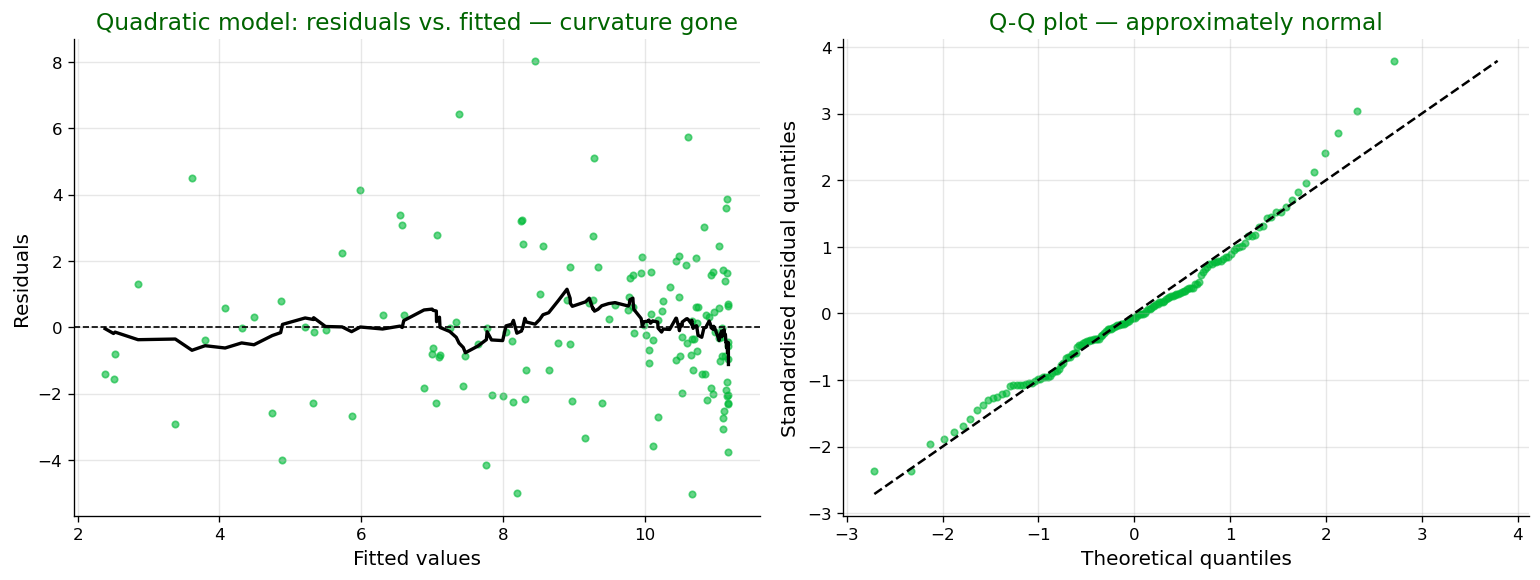

The curvature is gone. Some heteroscedasticity may remain (Breusch-Pagan
was borderline), but the functional form is now correct.

For the remaining heteroscedasticity, we could use robust standard errors.


In [ ]:
# Step 4: Check residuals again
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(fit2["y_hat"], fit2["residuals"], s=15, alpha=0.6, color=C_GOOD)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
order2 = np.argsort(fit2["y_hat"])
smoothed2 = uniform_filter1d(fit2["residuals"][order2], size=20)
axes[0].plot(fit2["y_hat"][order2], smoothed2, color="black", linewidth=2)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title(
    "Quadratic model: residuals vs. fitted — curvature gone", color="darkgreen"
)

# Q-Q plot
z_r = (fit2["residuals"] - fit2["residuals"].mean()) / fit2["residuals"].std()
theoretical = np.sort(stats.norm.ppf(np.linspace(0.5 / n_ex, 1 - 0.5 / n_ex, n_ex)))
empirical = np.sort(z_r)
axes[1].scatter(theoretical, empirical, s=15, alpha=0.6, color=C_GOOD)
lims = [
    min(theoretical.min(), empirical.min()),
    max(theoretical.max(), empirical.max()),
]
axes[1].plot(lims, lims, "k--", linewidth=1.5)
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Standardised residual quantiles")
axes[1].set_title("Q-Q plot — approximately normal", color="darkgreen")

plt.tight_layout()
plt.show()
print("The curvature is gone. Some heteroscedasticity may remain (Breusch-Pagan")
print("was borderline), but the functional form is now correct.")
print("\nFor the remaining heteroscedasticity, we could use robust standard errors.")

**Summary of the iterative approach:**

| Iteration | Model                                   | Residual diagnosis                    | Action                   |
|-----------|-----------------------------------------|---------------------------------------|--------------------------|
| 1         | $y = \beta_0 + \beta_1 x$               | Curvature + fan shape                 | Add $x^2$                |
| 2         | $y = \beta_0 + \beta_1 x + \beta_2 x^2$ | No curvature, mild heteroscedasticity | Use robust SEs if needed |

Each iteration was guided entirely by what the residuals told us. This is the essence of residual-driven model building.

---

## 7. The Four-Panel Diagnostic Plot

The standard diagnostic display — modelled after R's `plot(lm_object)` — consists of four panels:

1. **Residuals vs. Fitted** — check linearity, constant variance
2. **Normal Q-Q** — check normality of residuals
3. **Scale-Location** ($\sqrt{|\text{standardised residuals}|}$ vs. fitted) — check homoscedasticity more clearly
4. **Residuals vs. Leverage** — identify influential points (with Cook's distance contours)

### 7.1 From Scratch with Matplotlib

In [ ]:
def diagnostic_plots(X, y, title="Diagnostic Plots"):
    """Four-panel regression diagnostic plot, built from scratch."""
    fit = ols_fit(X, y)
    y_hat = fit["y_hat"]
    resid = fit["residuals"]
    r_std = fit["student_resid"]
    leverage = fit["leverage"]
    cooks = fit["cooks_d"]
    n, p = fit["n"], fit["p"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # --- Panel 1: Residuals vs Fitted ---
    ax = axes[0, 0]
    ax.scatter(y_hat, resid, s=15, alpha=0.6, color=C_PT)
    ax.axhline(0, color="grey", linewidth=1, linestyle="--")
    order = np.argsort(y_hat)
    smoothed = uniform_filter1d(resid[order], size=max(n // 8, 5))
    ax.plot(y_hat[order], smoothed, color=C_BAD, linewidth=2)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title("Residuals vs Fitted")

    # --- Panel 2: Normal Q-Q ---
    ax = axes[0, 1]
    z_r = (resid - resid.mean()) / resid.std()
    theoretical = np.sort(stats.norm.ppf(np.linspace(0.5 / n, 1 - 0.5 / n, n)))
    empirical = np.sort(z_r)
    ax.scatter(theoretical, empirical, s=15, alpha=0.6, color=C_PT)
    lims = [
        min(theoretical.min(), empirical.min()) - 0.2,
        max(theoretical.max(), empirical.max()) + 0.2,
    ]
    ax.plot(lims, lims, "k--", linewidth=1.5)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Standardised Residuals")
    ax.set_title("Normal Q-Q")

    # --- Panel 3: Scale-Location ---
    ax = axes[1, 0]
    sqrt_abs_r = np.sqrt(np.abs(r_std))
    ax.scatter(y_hat, sqrt_abs_r, s=15, alpha=0.6, color=C_PT)
    order2 = np.argsort(y_hat)
    smoothed2 = uniform_filter1d(sqrt_abs_r[order2], size=max(n // 8, 5))
    ax.plot(y_hat[order2], smoothed2, color=C_BAD, linewidth=2)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("$\\sqrt{|\\text{Standardised Residuals}|}$")
    ax.set_title("Scale-Location")

    # --- Panel 4: Residuals vs Leverage ---
    ax = axes[1, 1]
    ax.scatter(leverage, r_std, s=15, alpha=0.6, color=C_PT)
    ax.axhline(0, color="grey", linewidth=1, linestyle="--")
    # Cook's distance contours
    h_range = np.linspace(0.001, min(leverage.max() * 1.5, 0.99), 200)
    for D_val in [0.5, 1.0]:
        # D = r^2/p * h/(1-h) => r = sqrt(D*p*(1-h)/h)
        r_contour = np.sqrt(D_val * p * (1 - h_range) / h_range)
        valid = r_contour < max(np.abs(r_std)) * 1.5
        ax.plot(h_range[valid], r_contour[valid], "r--", linewidth=1, alpha=0.6)
        ax.plot(h_range[valid], -r_contour[valid], "r--", linewidth=1, alpha=0.6)
        # Label
        if np.any(valid):
            idx = np.sum(valid) // 2
            ax.annotate(
                f"$D={D_val}$",
                xy=(h_range[valid][idx], r_contour[valid][idx]),
                fontsize=9,
                color="red",
                alpha=0.7,
            )
    ax.set_xlabel("Leverage $h_{ii}$")
    ax.set_ylabel("Standardised Residuals")
    ax.set_title("Residuals vs Leverage")

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    return fit

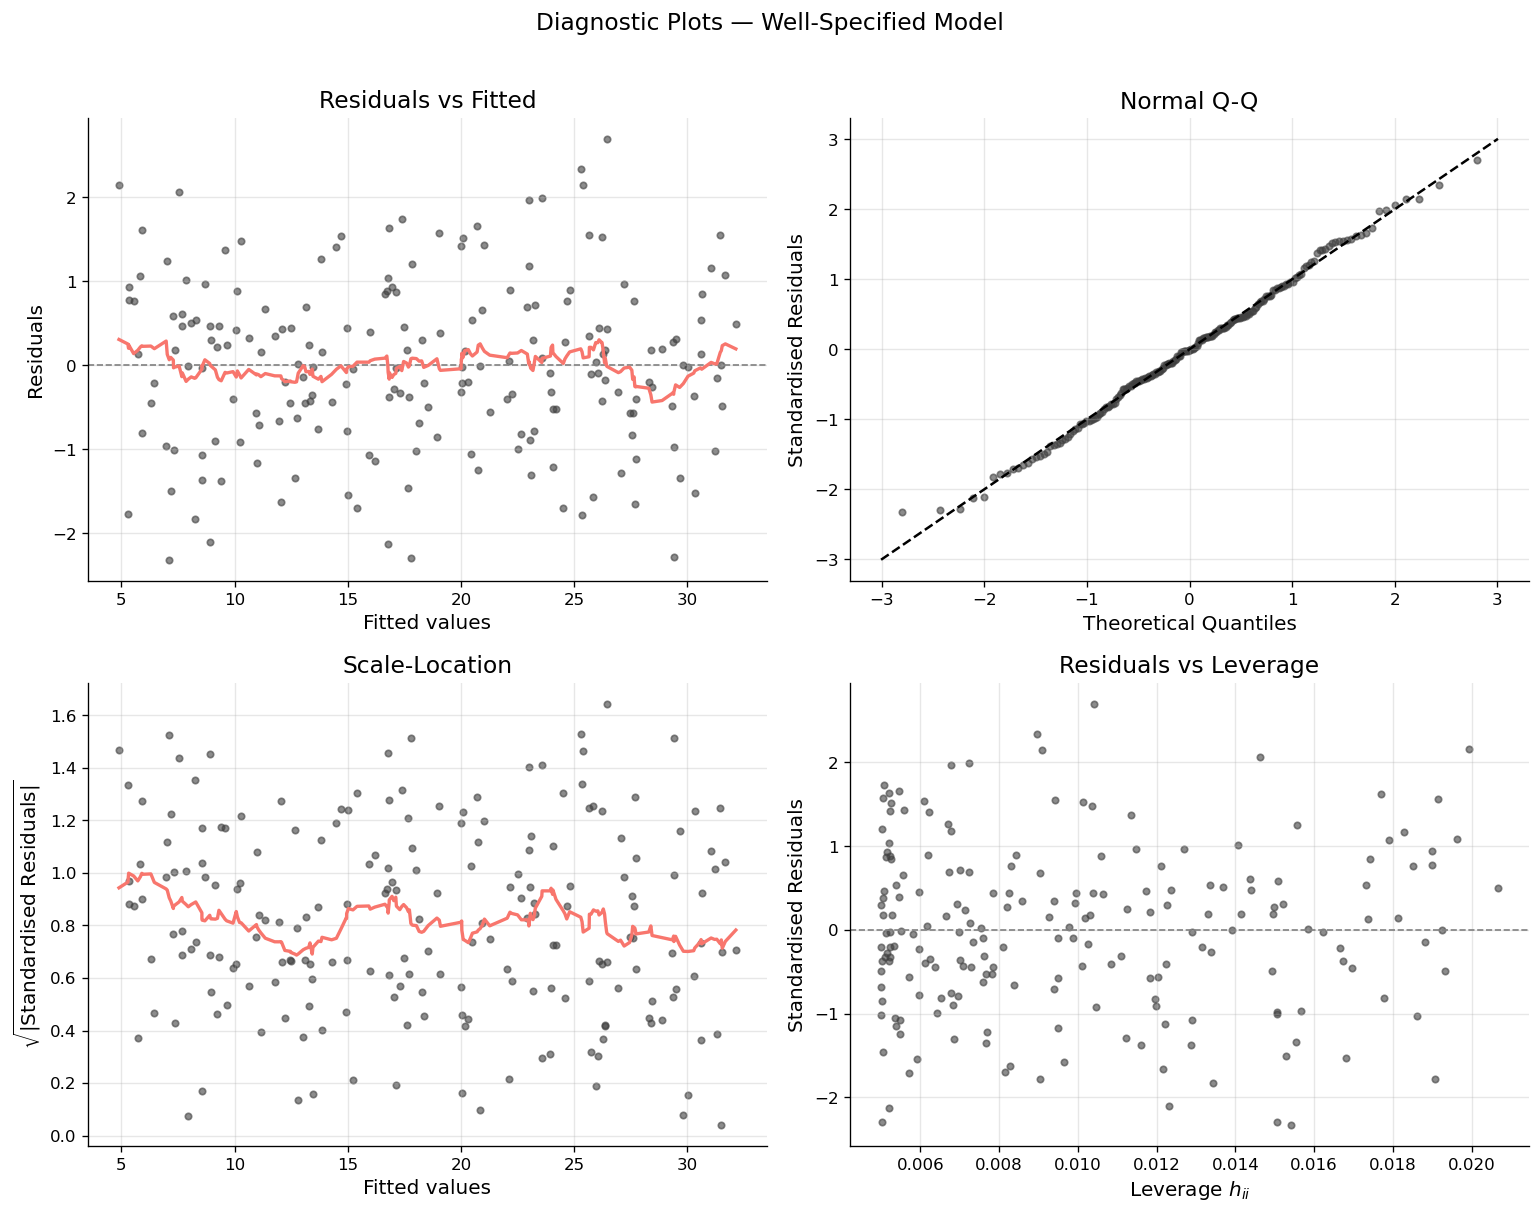

In [17]:
# Apply to the good model
_ = diagnostic_plots(X, y_good, title="Diagnostic Plots — Well-Specified Model")

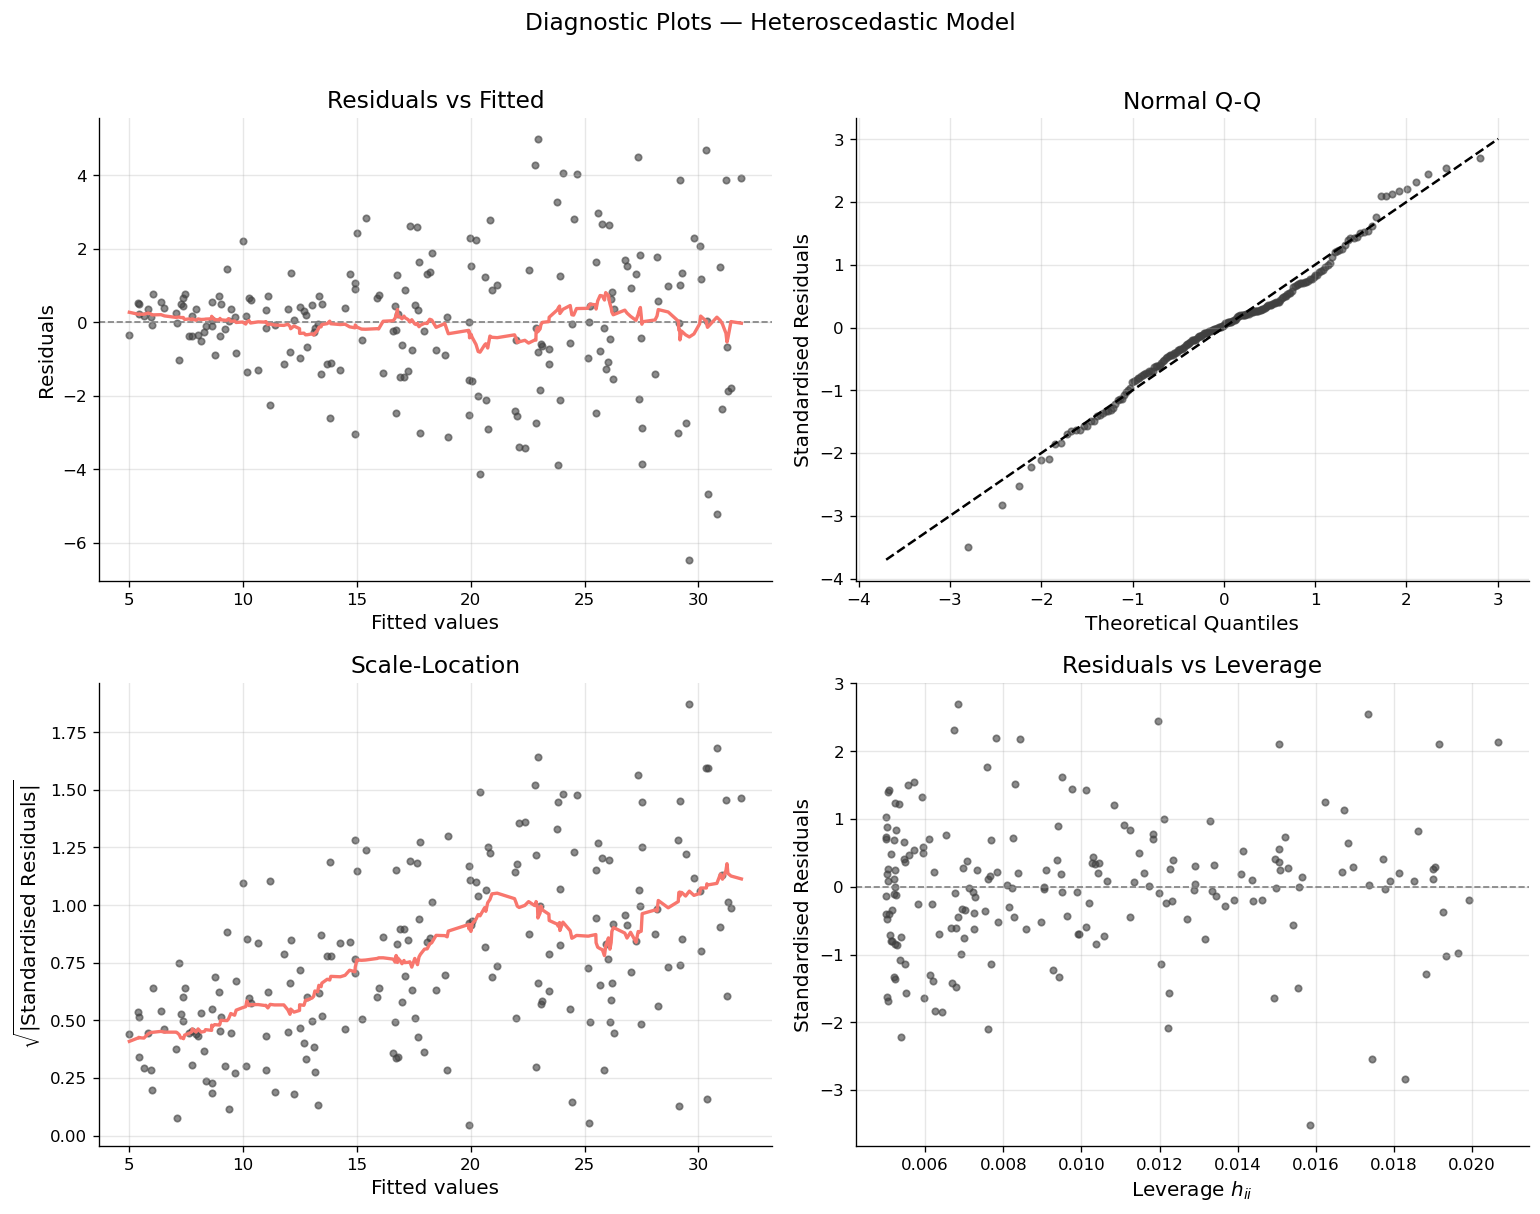

In [18]:
# Apply to the heteroscedastic model
_ = diagnostic_plots(X, y_hetero, title="Diagnostic Plots — Heteroscedastic Model")

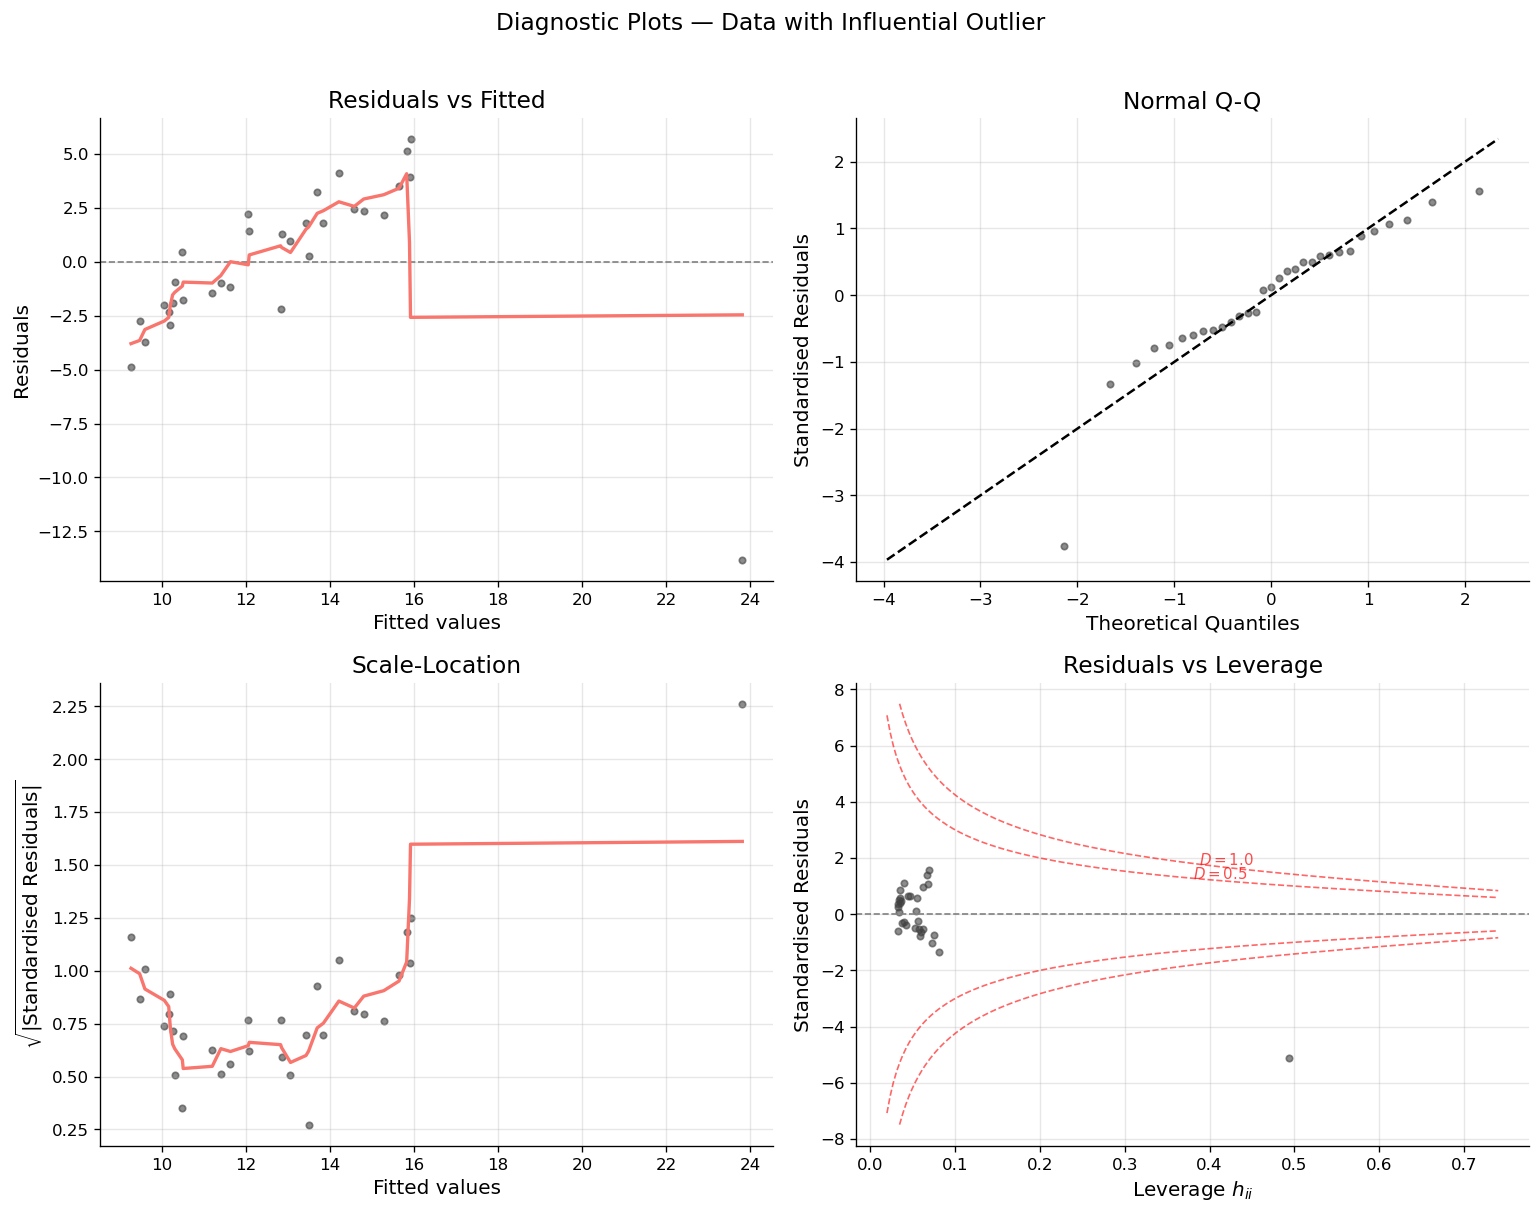

In [ ]:
# Apply to the data with an influential outlier
_ = diagnostic_plots(
    X_infl, y_infl, title="Diagnostic Plots — Data with Influential Outlier"
)

### 7.2 Using statsmodels

The `statsmodels` library provides built-in diagnostic plots through `statsmodels.graphics`. Let's compare our from-scratch plots to the professional version.

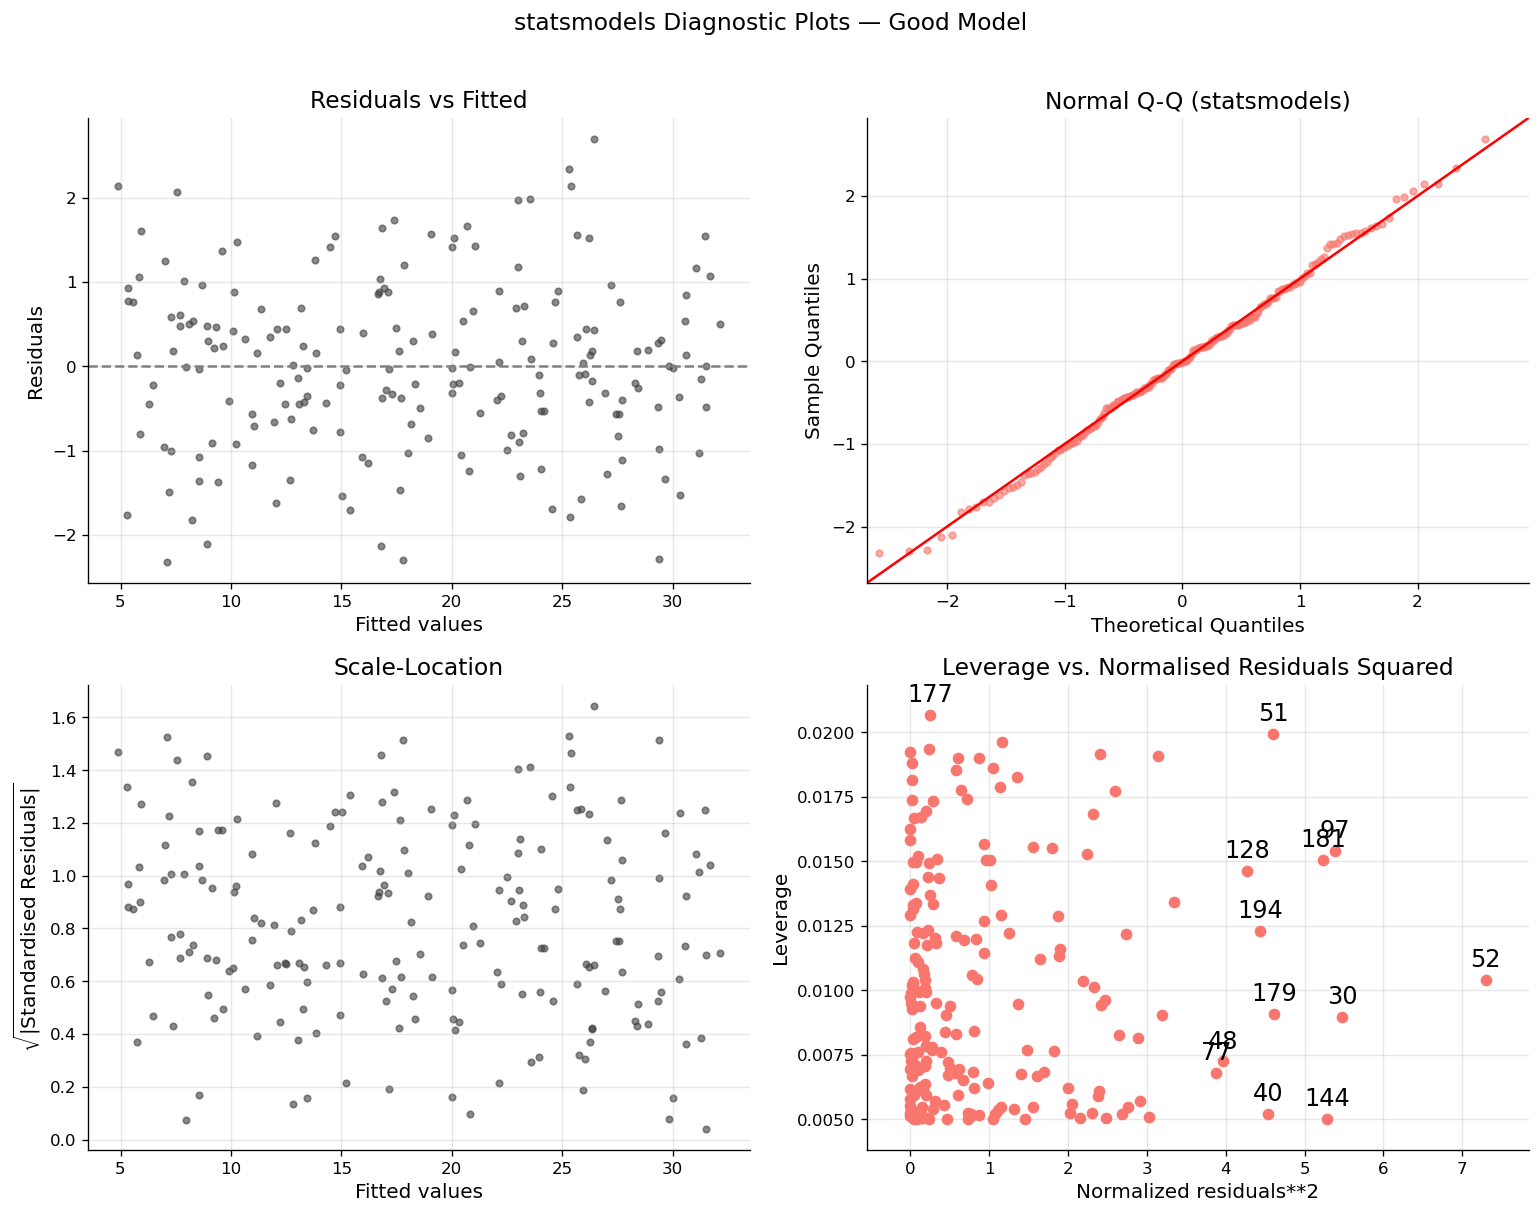

In [ ]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_leverage_resid2

# Fit model with statsmodels
model_good = sm.OLS(y_good, X).fit()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel 1: Residuals vs fitted
axes[0, 0].scatter(
    model_good.fittedvalues, model_good.resid, s=15, alpha=0.6, color=C_PT
)
axes[0, 0].axhline(0, color="grey", linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# Panel 2: Q-Q plot using statsmodels
sm.qqplot(model_good.resid, line="45", ax=axes[0, 1], markersize=4, alpha=0.6)
axes[0, 1].set_title("Normal Q-Q (statsmodels)")

# Panel 3: Scale-location
influence = model_good.get_influence()
std_resid = influence.resid_studentized_internal
axes[1, 0].scatter(
    model_good.fittedvalues, np.sqrt(np.abs(std_resid)), s=15, alpha=0.6, color=C_PT
)
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("$\\sqrt{|\\text{Standardised Residuals}|}$")
axes[1, 0].set_title("Scale-Location")

# Panel 4: Leverage vs. residuals squared
plot_leverage_resid2(model_good, ax=axes[1, 1])
axes[1, 1].set_title("Leverage vs. Normalised Residuals Squared")

fig.suptitle("statsmodels Diagnostic Plots — Good Model", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Useful summary: influence statistics from statsmodels
model_infl = sm.OLS(y_infl, X_infl).fit()
infl_table = model_infl.get_influence().summary_frame()

print("Influence statistics for the dataset with one outlier:")
print("(Showing the 5 most influential observations by Cook's distance)")
print()
top5 = infl_table.nlargest(5, "cooks_d")[["hat_diag", "student_resid", "cooks_d"]]
top5.columns = ["Leverage h_ii", "Studentised Resid", "Cook's D"]
print(top5.to_string(float_format="{:.4f}".format))

Influence statistics for the dataset with one outlier:
(Showing the 5 most influential observations by Cook's distance)

    Leverage h_ii  Studentised Resid  Cook's D
30         0.4936           -16.1380   12.7629
10         0.0686             1.5994    0.0895
0          0.0810            -1.3633    0.0795
27         0.0665             1.4228    0.0697
15         0.0681             1.0766    0.0421


---

## 8. Exercises

**Exercise 3.1 (Interpreting diagnostic plots).** The code below generates a mystery dataset and fits a linear model. Produce the four-panel diagnostic plot (using our `diagnostic_plots` function) and answer:
- Which assumptions appear violated?
- What specific pattern in each plot leads you to that conclusion?
- What would you change about the model?

In [ ]:
# Exercise 3.1 — Mystery dataset
rng_ex = np.random.default_rng(123)
x_mystery = rng_ex.uniform(0.5, 8, 120)
y_mystery = 3 * np.log(x_mystery) + rng_ex.normal(0, 0.5, 120)
X_mystery = np.column_stack([np.ones(120), x_mystery])

# YOUR CODE: call diagnostic_plots(X_mystery, y_mystery) and interpret

**Exercise 3.2 (Breusch-Pagan by hand).** Using the heteroscedastic data from Section 3 (`x`, `y_hetero`):
1. Fit the OLS model and compute residuals.
2. Compute $g_i = e_i^2 / \hat{\sigma}^2$.
3. Regress $g_i$ on $x$ (with an intercept) and compute $R^2$.
4. Compute the test statistic $\text{BP} = nR^2$ and the p-value.
5. Verify that your result matches `breusch_pagan_test(X, fit["residuals"])`.

In [ ]:
# Exercise 3.2 — your code here

**Exercise 3.3 (Intentional violation).** Generate data from the model $y = 5 + 2x + \varepsilon$ where $\varepsilon \sim \text{Exponential}(1) - 1$ (mean-zero but right-skewed errors, $n = 200$). Fit the OLS model and produce:
1. A residuals vs. fitted plot.
2. A Q-Q plot.
3. A histogram of residuals with a normal density overlay.

Is $\hat{\beta}_1$ still close to 2? Are the standard errors from `sm.OLS(...).fit().summary()` trustworthy? What does the Q-Q plot look like for skewed errors?

In [ ]:
# Exercise 3.3 — your code here

**Exercise 3.4 (Cook's distance deep dive).** Using the dataset with the influential outlier from Section 5 (`X_infl`, `y_infl`):
1. Verify Cook's distance for observation 30 by actually removing it, refitting the model, and computing the change in fitted values: $D_i = \frac{(\hat{\mathbf{y}} - \hat{\mathbf{y}}_{(-i)})^\top (\hat{\mathbf{y}} - \hat{\mathbf{y}}_{(-i)})}{p \cdot \hat{\sigma}^2}$.
2. Does your direct calculation match the formula $D_i = \frac{r_i^2}{p} \cdot \frac{h_{ii}}{1 - h_{ii}}$?

In [ ]:
# Exercise 3.4 — your code here

**Exercise 3.5 (Full diagnostic workflow).** Load or generate a dataset with *multiple* problems — e.g., generate $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2^2 + \varepsilon$ where $\varepsilon$ has variance proportional to $x_1$, but fit only $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon$ (linear in both predictors). Perform the full iterative diagnostic workflow:
1. Fit the initial (wrong) model.
2. Diagnose with the four-panel plot and Breusch-Pagan test.
3. Fix the functional form (add $x_2^2$).
4. Re-diagnose — is the heteroscedasticity still present?
5. If so, compute robust standard errors using `sm.OLS(...).fit(cov_type='HC3')`.
6. Compare the naive and robust standard errors.

In [ ]:
# Exercise 3.5 — your code here

---

## Key Takeaways

1. **OLS always produces numbers** — but those numbers are only trustworthy if the model assumptions hold. Residual analysis is how you check.
2. The **four OLS assumptions** are linearity, independence, homoscedasticity, and normality. Each has a specific diagnostic plot and formal test.
3. **Residuals vs. fitted values** is the single most important diagnostic: it reveals nonlinearity and heteroscedasticity simultaneously.
4. **Q-Q plots** detect non-normality — look for S-shapes (heavy tails) and curvature (skew).
5. **Heteroscedasticity** does not bias $\hat{\boldsymbol{\beta}}$ but invalidates standard errors. Use the Breusch-Pagan test to detect it, and robust standard errors (HC3) to handle it.
6. **Leverage** ($h_{ii}$) measures how unusual an observation's predictor values are; **Cook's distance** combines leverage with residual size to measure **influence**.
7. **Residual-driven model building** is iterative: fit, diagnose, fix, repeat. Let the residuals guide you.
8. The **four-panel diagnostic plot** (residuals vs. fitted, Q-Q, scale-location, residuals vs. leverage) is the standard toolkit — know what each panel tells you.

**Next:** [04_anova.ipynb](04_anova.ipynb) — Analysis of Variance: comparing group means, the F-test as a regression test, one-way and two-way ANOVA.

In [22]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
